# Who Bankrolls U.K. politicians?

This code uses the data imported from [Donation Watch](https://donation.watch/en/unitedkingdom/tools/data) under the [CC BY 4.0 license](https://creativecommons.org/licenses/by/4.0/).

Politian talk a lot. But their House of Commons votes, the laws they pass and policies they enable will never step over the sweet, sweet lifeline that is their donation lifeline.

When you vote, you vote for the benefit of these mysterious donors. But who are they? Where do parties get their money from?

Why should you even care?

This data analysis of the (*known*) donations political parties get will hopefully help address these questions, *as objectively as one can*.

In [33]:
# Library imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path

In [34]:
# plot config

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

OUTPUT_DIR = Path('article/figures')
OUTPUT_DIR.mkdir(exist_ok=True)

PARTY_COLOURS = {
    'Conservative Party': '#0087DC',
    'Labour': '#E4003B',
    'Lib Dems': '#FAA61A',
    'Scottish National Party': '#FDF38E',
    'Plaid Cymru': '#00750F',
    'Reform UK': '#12B6CF',
    'Green Party': '#02A95B',
    'Other': '#AAAAAA',
}

## Data cleaning, formatting, &c.

In [35]:
# importing pandas module  
import pandas as pd  
    
# making data frame  
df = pd.read_csv("data/DonationWatch-donations-unitedkingdom-2026-06-09.csv")  
  
df.head(10)

,Date,Donor Name,Receiver,Amount,Currency,Donor Type
0,2010-01-01,Hanlon & Wright Ltd,Labour,2000.0,GBP,Company
1,2010-01-01,Co-operative Party - Sponsorship,Labour,1520.0,GBP,Registered Political Party
2,2010-01-01,Unite the Union,Labour,12000.0,GBP,Trade union
3,2010-01-01,John C C Stevens,The Buckinghamshire Campaign for Democracy,30000.0,GBP,Individual
4,2010-01-01,Co-operative Group (CWS) Ltd,Co-operative Party,1250.0,GBP,Friendly Society
5,2010-01-01,Co-operatives UK Ltd,Co-operative Party,6000.0,GBP,Friendly Society
6,2010-01-01,Unite the Union,Labour,1125.0,GBP,Trade union
7,2010-01-02,Dermot Smurfit,Conservative Party,3000.0,GBP,Individual
8,2010-01-02,Matthew Sellwood,Green Party,1650.0,GBP,Individual
9,2010-01-02,Co-operative Party,Labour,3040.0,GBP,Registered Political Party


In [36]:
print(df['Receiver'].unique())

<StringArray>
[                                               'Labour',
            'The Buckinghamshire Campaign for Democracy',
                                    'Co-operative Party',
                                    'Conservative Party',
                                           'Green Party',
                                              'Lib Dems',
                                                  'UKIP',
                               'Scottish National Party',
                                         'The New Party',
       'Christian Party "Proclaiming Christ's Lordship"',
                                           'Plaid Cymru',
                                             'Jury Team',
                            'Freedom and Responsibility',
 'Independent Kidderminster Hospital and Health Concern',
                                                   'CPA',
            'Solihull and Meriden Residents Association',
                            'Pro Democracy: Libertas.eu',


In [37]:
# check that there is no need to convert currencies
unique_currencies = df['Currency'].unique()
print(unique_currencies)

<StringArray>
['GBP']
Length: 1, dtype: str


In [38]:
# convert Date from string to date format:
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)

Date          datetime64[us]
Donor Name               str
Receiver                 str
Amount               float64
Currency                 str
Donor Type               str
dtype: object


In [39]:
# for now, minor parties will be ignored

# Consolidate minor parties into 'Other'
major_parties = list(PARTY_COLOURS.keys())[:-1]   # all except 'Other'
df['party_group'] = df['Receiver'].where(df['Receiver'].isin(major_parties), other='Other')

print(df['party_group'].unique())

<StringArray>
[                 'Labour',                   'Other',
      'Conservative Party',             'Green Party',
                'Lib Dems', 'Scottish National Party',
             'Plaid Cymru',               'Reform UK']
Length: 8, dtype: str


In [40]:
print(f"Donations: {len(df):,}  |  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head(3)

Donations: 46,350  |  Date range: 2010-01-01 to 2026-04-01


,Date,Donor Name,Receiver,Amount,Currency,Donor Type,party_group
0,2010-01-01,Hanlon & Wright Ltd,Labour,2000.0,GBP,Company,Labour
1,2010-01-01,Co-operative Party - Sponsorship,Labour,1520.0,GBP,Registered Political Party,Labour
2,2010-01-01,Unite the Union,Labour,12000.0,GBP,Trade union,Labour


## Preliminary Visualisation

### Parties

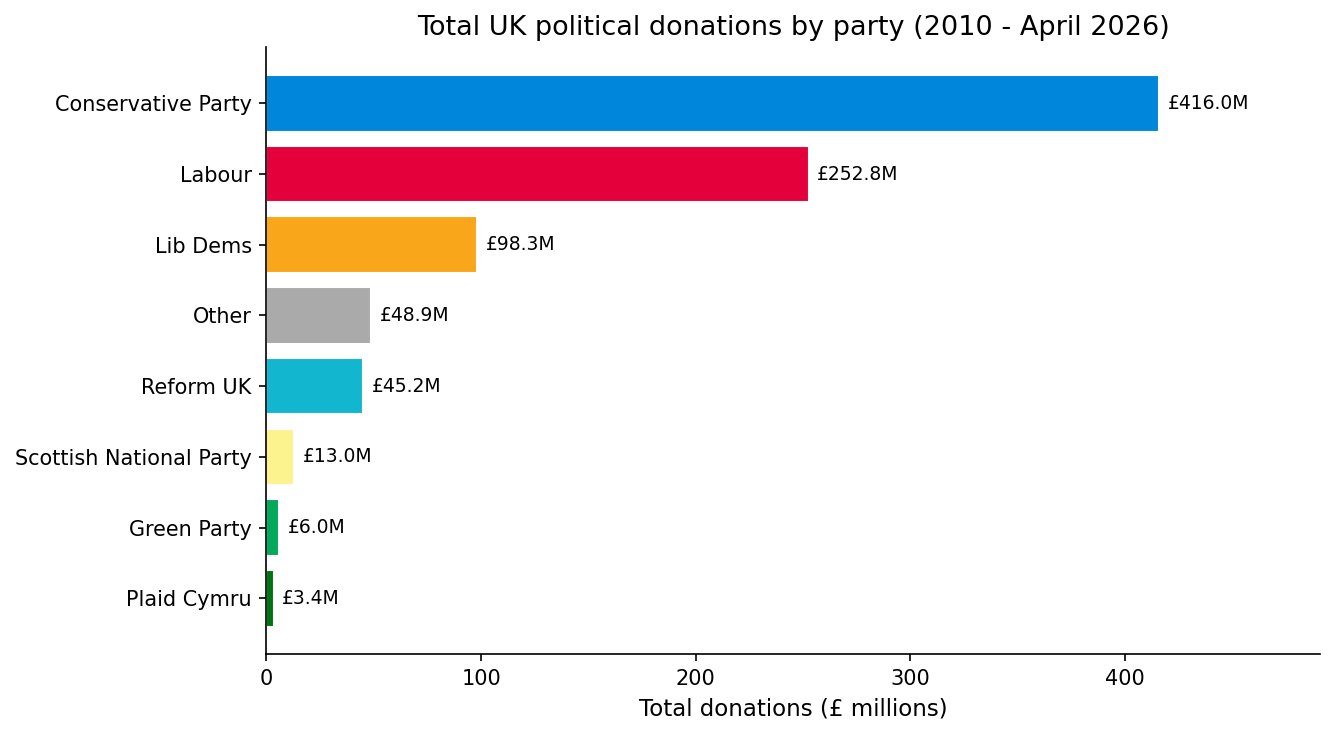

In [41]:
party_totals = (
    df.groupby('party_group')['Amount']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colours = [PARTY_COLOURS.get(p, '#AAAAAA') for p in party_totals.index]
bars = ax.barh(party_totals.index, party_totals.values / 1e6, color=colours, edgecolor='white')
ax.set_xlabel('Total donations (£ millions)')
ax.set_title('Total UK political donations by party (2010 - April 2026)')
ax.bar_label(bars, fmt='£%.1fM', padding=4, fontsize=9)
ax.set_xlim(0, party_totals.values.max() / 1e6 * 1.18)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'major_parties_total_by_party.png')
plt.show()

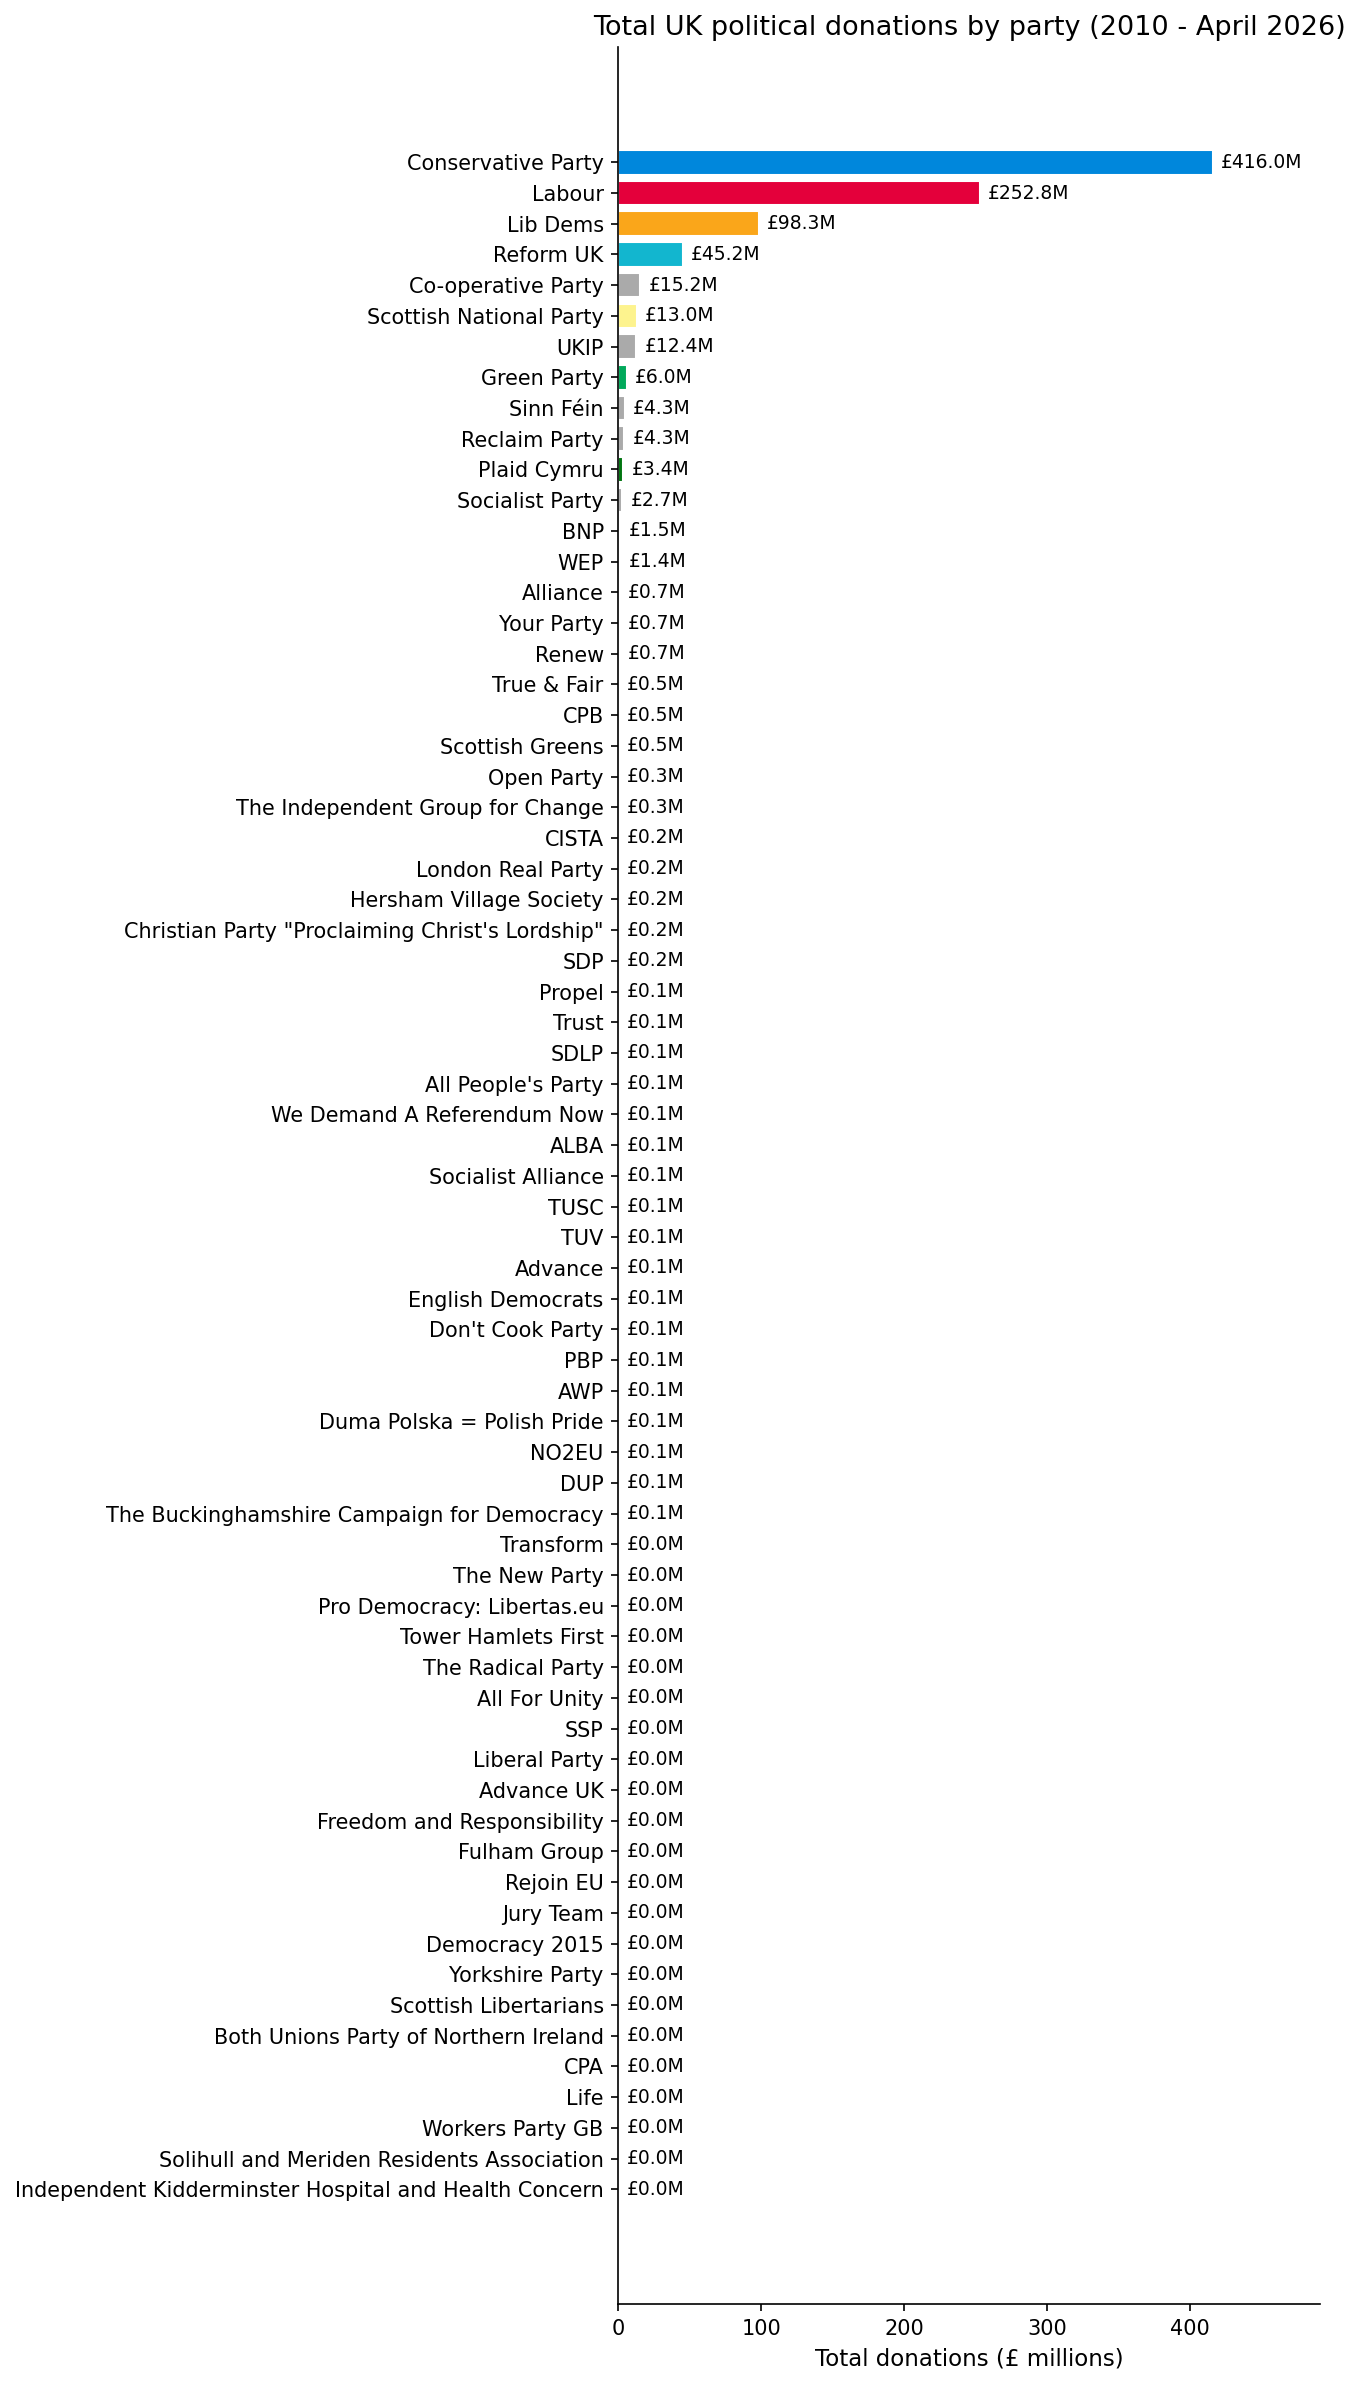

In [42]:
party_totals = (
    df.groupby('Receiver')['Amount']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 16))
colours = [PARTY_COLOURS.get(p, '#AAAAAA') for p in party_totals.index]
bars = ax.barh(party_totals.index, party_totals.values / 1e6, color=colours, edgecolor='white')
ax.set_xlabel('Total donations (£ millions)')
ax.set_title('Total UK political donations by party (2010 - April 2026)')
ax.bar_label(bars, fmt='£%.1fM', padding=4, fontsize=9)
ax.set_xlim(0, party_totals.values.max() / 1e6 * 1.18)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_parties.png')
plt.show()

TODO: When updating the dataset, setting the PARTY_COLOURS variable based on a donation threshold + vote relevance will be necessary.

### Donor Entities

In [44]:
print(df['Donor Type'].unique())

<StringArray>
[                      'Company',    'Registered Political Party',
                   'Trade union',                    'Individual',
              'Friendly Society',    'Unincorporated Association',
                         'Trust',                         'Other',
 'Limited Liability Partnership',                   'Public fund']
Length: 10, dtype: str
